# CSCN8020 Assignment 2 - Taxi Gymnasium Environment with Q-Learning

**Student name:** Ce Chen  
**Student ID:** `YOUR_STUDENT_ID`  
**Course:** CSCN8020  
**Repository:** `https://github.com/YOUR_GITHUB_USRID/CSCN8020_Assignment2`

## Short introduction

This notebook implements Q-Learning in the Taxi Gymnasium environment. The taxi agent must move on a small grid, pick up a passenger, and drop the passenger at the correct destination.

The goal is not only to train the agent. This notebook also explains the reinforcement learning ideas, maps the code to Q-Learning pseudocode, records metrics, tests hyperparameters, and saves a log file.

## Taxi environment

The Taxi environment is a discrete reinforcement learning problem.

### Action space

There are 6 actions:

| Action number | Meaning |
|---|---|
| 0 | Move south / down |
| 1 | Move north / up |
| 2 | Move east / right |
| 3 | Move west / left |
| 4 | Pick up passenger |
| 5 | Drop off passenger |

### Observation space

There are 500 discrete states. A state is encoded as one integer. It combines:

- taxi row and column,
- passenger location,
- destination location.

The state encoding is:

$$
((taxi\ row \times 5 + taxi\ col) \times 5 + passenger\ location) \times 4 + destination
$$

### Reward structure

The rewards are:

- `-1` for each step,
- `+20` for a successful drop-off,
- `-10` for illegal pickup or drop-off.

This reward design encourages the taxi to finish the task quickly and avoid illegal actions.

## Q-Learning explanation

Q-Learning is a value-based reinforcement learning algorithm. It learns a value for each state-action pair, written as $Q(s,a)$.

The update equation is:

$$
Q(S,A) \leftarrow Q(S,A) + \alpha \left[R + \gamma \max_a Q(S',a) - Q(S,A)\right]
$$

Where:

- $S$ is the current state,
- $A$ is the selected action,
- $R$ is the reward,
- $S'$ is the next state,
- $\alpha$ is the learning rate,
- $\gamma$ is the discount factor.

In this assignment, the baseline hyperparameters are:

- learning rate $\alpha = 0.1$,
- exploration factor $\epsilon = 0.1$,
- discount factor $\gamma = 0.9$.

The agent uses an epsilon-greedy strategy. With probability $\epsilon$, it explores by selecting a random action. Otherwise, it exploits the current Q-table by selecting the action with the highest Q-value.

In [45]:
# Imports
from __future__ import annotations

import logging
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [46]:
# Global settings
RANDOM_SEED = 42
LOG_FILE = "assignment2_execution.log"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [47]:
@dataclass
class ExperimentConfig:
    """Stores the settings for one Q-Learning experiment."""
    name: str
    alpha: float
    epsilon: float
    gamma: float = 0.9
    episodes: int = 3000
    max_steps_per_episode: int = 200
    eval_episodes: int = 100
    seed: int = RANDOM_SEED

In [48]:
class AppLogger:
    """Creates one readable log file for the assignment."""

    def __init__(self, log_file: str = LOG_FILE):
        self.log_file = log_file
        self.logger = logging.getLogger("TaxiQLearningAssignment")
        self.logger.setLevel(logging.INFO)
        self.logger.handlers = []

        formatter = logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S"
        )

        file_handler = logging.FileHandler(self.log_file, mode="w", encoding="utf-8")
        file_handler.setFormatter(formatter)
        self.logger.addHandler(file_handler)

        stream_handler = logging.StreamHandler()
        stream_handler.setFormatter(formatter)
        self.logger.addHandler(stream_handler)

    def info(self, message: str) -> None:
        self.logger.info(message)

    def warning(self, message: str) -> None:
        self.logger.warning(message)

In [49]:
class TaxiEnvironmentManager:
    """Handles the Gymnasium Taxi environment."""

    def __init__(self, env_name: str = "Taxi-v4", seed: int = RANDOM_SEED):
        self.env_name = env_name
        self.seed = seed
        self.env = gym.make(env_name)
        self.state_count = self.env.observation_space.n
        self.action_count = self.env.action_space.n
        self.current_episode = 0

    def reset(self) -> int:
        """Reset the environment and return the starting state."""
        # Change the seed slightly each episode so training is not exactly the same start every time.
        obs, _ = self.env.reset(seed=self.seed + self.current_episode)
        self.current_episode += 1
        return int(obs)

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        """Take one action and return next_state, reward, done, info."""
        next_obs, reward, terminated, truncated, info = self.env.step(action)
        done = bool(terminated or truncated)
        return int(next_obs), float(reward), done, info

    def decode_state(self, state: int) -> Tuple[int, int, int, int]:
        """Decode a Taxi state into taxi row, taxi col, passenger location, and destination."""
        return tuple(self.env.unwrapped.decode(state))

    def close(self) -> None:
        self.env.close()

In [50]:
class QLearningAgent:
    """Q-Learning agent with epsilon-greedy action selection."""

    def __init__(
        self,
        state_count: int,
        action_count: int,
        alpha: float,
        epsilon: float,
        gamma: float,
        seed: int = RANDOM_SEED,
    ):
        self.state_count = state_count
        self.action_count = action_count
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma
        self.rng = np.random.default_rng(seed)
        self.q_table = np.zeros((state_count, action_count))

    def choose_action(self, state: int) -> int:
        """Choose an action using epsilon-greedy exploration."""
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.action_count))
        return self.greedy_action(state)

    def greedy_action(self, state: int) -> int:
        """Choose one of the best actions. Random tie-breaking avoids always choosing action 0."""
        q_values = self.q_table[state]
        best_value = np.max(q_values)
        best_actions = np.flatnonzero(q_values == best_value)
        return int(self.rng.choice(best_actions))

    def learn(self, state: int, action: int, reward: float, next_state: int, done: bool) -> None:
        """Apply the Q-Learning update rule."""
        old_value = self.q_table[state, action]
        next_best_value = 0.0 if done else np.max(self.q_table[next_state])
        target = reward + self.gamma * next_best_value
        td_error = target - old_value
        self.q_table[state, action] = old_value + self.alpha * td_error

In [51]:
class MetricsCollector:
    """Collects training metrics for one experiment."""

    def __init__(self):
        self.episode_numbers: List[int] = []
        self.returns: List[float] = []
        self.steps: List[int] = []

    def add(self, episode: int, total_return: float, steps: int) -> None:
        self.episode_numbers.append(episode)
        self.returns.append(total_return)
        self.steps.append(steps)

    def to_dataframe(self, experiment_name: str) -> pd.DataFrame:
        df = pd.DataFrame({
            "episode": self.episode_numbers,
            "return": self.returns,
            "steps": self.steps,
        })
        df["experiment"] = experiment_name
        df["average_return_so_far"] = df["return"].expanding().mean()
        df["moving_avg_return_100"] = df["return"].rolling(window=100, min_periods=1).mean()
        df["moving_avg_steps_100"] = df["steps"].rolling(window=100, min_periods=1).mean()
        return df

In [52]:
class QLearningTrainer:
    """Runs the training loop and policy evaluation."""

    def __init__(
        self,
        env_manager: TaxiEnvironmentManager,
        agent: QLearningAgent,
        config: ExperimentConfig,
        logger: AppLogger,
    ):
        self.env_manager = env_manager
        self.agent = agent
        self.config = config
        self.logger = logger

    def train(self) -> pd.DataFrame:
        metrics = MetricsCollector()
        self.logger.info(
            f"Start training | experiment={self.config.name} | "
            f"alpha={self.config.alpha} | epsilon={self.config.epsilon} | gamma={self.config.gamma} | "
            f"episodes={self.config.episodes}"
        )

        log_interval = max(1, self.config.episodes // 10)

        for episode in range(1, self.config.episodes + 1):
            state = self.env_manager.reset()
            total_return = 0.0
            steps = 0
            done = False

            while not done and steps < self.config.max_steps_per_episode:
                action = self.agent.choose_action(state)
                next_state, reward, done, _ = self.env_manager.step(action)
                self.agent.learn(state, action, reward, next_state, done)

                state = next_state
                total_return += reward
                steps += 1

            metrics.add(episode, total_return, steps)

            if episode % log_interval == 0:
                recent_returns = metrics.returns[-log_interval:]
                recent_steps = metrics.steps[-log_interval:]
                self.logger.info(
                    f"Progress | experiment={self.config.name} | episode={episode}/{self.config.episodes} | "
                    f"recent_avg_return={np.mean(recent_returns):.2f} | recent_avg_steps={np.mean(recent_steps):.2f}"
                )

        df = metrics.to_dataframe(self.config.name)
        self.logger.info(
            f"End training | experiment={self.config.name} | "
            f"final_100_avg_return={df['return'].tail(100).mean():.2f} | "
            f"final_100_avg_steps={df['steps'].tail(100).mean():.2f}"
        )
        return df

    def evaluate_policy(self, episodes: Optional[int] = None) -> Dict[str, float]:
        """Evaluate the learned greedy policy without exploration or learning."""
        if episodes is None:
            episodes = self.config.eval_episodes

        returns = []
        steps_list = []
        successes = 0

        old_epsilon = self.agent.epsilon
        self.agent.epsilon = 0.0

        for _ in range(episodes):
            state = self.env_manager.reset()
            total_return = 0.0
            steps = 0
            done = False
            success = False

            while not done and steps < self.config.max_steps_per_episode:
                action = self.agent.greedy_action(state)
                next_state, reward, done, _ = self.env_manager.step(action)
                state = next_state
                total_return += reward
                steps += 1

                if reward == 20:
                    success = True

            returns.append(total_return)
            steps_list.append(steps)
            if success:
                successes += 1

        self.agent.epsilon = old_epsilon

        results = {
            "eval_avg_return": float(np.mean(returns)),
            "eval_avg_steps": float(np.mean(steps_list)),
            "eval_success_rate": float(successes / episodes),
        }

        self.logger.info(
            f"Evaluation | experiment={self.config.name} | "
            f"avg_return={results['eval_avg_return']:.2f} | "
            f"avg_steps={results['eval_avg_steps']:.2f} | "
            f"success_rate={results['eval_success_rate']:.2f}"
        )
        return results

In [53]:
class PlotManager:
    """Creates and saves plots for the experiments."""

    @staticmethod
    def plot_training_curves(df: pd.DataFrame, experiment_name: str) -> None:
        safe_name = experiment_name.replace(" ", "_").replace("=", "")

        plt.figure(figsize=(10, 5))
        plt.plot(df["episode"], df["return"], alpha=0.35, label="Return per episode")
        plt.plot(df["episode"], df["moving_avg_return_100"], label="Moving average return (100 episodes)")
        plt.xlabel("Episode")
        plt.ylabel("Return")
        plt.title(f"Return per Episode - {experiment_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{safe_name}_return.png", dpi=150)
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(df["episode"], df["steps"], alpha=0.35, label="Steps per episode")
        plt.plot(df["episode"], df["moving_avg_steps_100"], label="Moving average steps (100 episodes)")
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.title(f"Steps per Episode - {experiment_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{safe_name}_steps.png", dpi=150)
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(df["episode"], df["average_return_so_far"], label="Average return so far")
        plt.xlabel("Episode")
        plt.ylabel("Average return")
        plt.title(f"Average Return Over Time - {experiment_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{safe_name}_average_return.png", dpi=150)
        plt.show()

    @staticmethod
    def plot_experiment_comparison(summary_df: pd.DataFrame) -> None:
        plt.figure(figsize=(12, 5))
        plt.bar(summary_df["experiment"], summary_df["eval_avg_return"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Evaluation average return")
        plt.title("Experiment Comparison by Evaluation Average Return")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "experiment_comparison_eval_return.png", dpi=150)
        plt.show()

        plt.figure(figsize=(12, 5))
        plt.bar(summary_df["experiment"], summary_df["eval_avg_steps"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Evaluation average steps")
        plt.title("Experiment Comparison by Evaluation Average Steps")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "experiment_comparison_eval_steps.png", dpi=150)
        plt.show()

In [54]:
class ExperimentRunner:
    """Runs baseline, hyperparameter experiments, and the best-combination experiment."""

    def __init__(self, logger: AppLogger):
        self.logger = logger
        self.training_results: Dict[str, pd.DataFrame] = {}
        self.summary_rows: List[Dict] = []

    def run_experiment(self, config: ExperimentConfig, plot: bool = False) -> Tuple[pd.DataFrame, Dict[str, float]]:
        env_manager = TaxiEnvironmentManager(seed=config.seed)
        agent = QLearningAgent(
            state_count=env_manager.state_count,
            action_count=env_manager.action_count,
            alpha=config.alpha,
            epsilon=config.epsilon,
            gamma=config.gamma,
            seed=config.seed,
        )
        trainer = QLearningTrainer(env_manager, agent, config, self.logger)
        df = trainer.train()
        eval_results = trainer.evaluate_policy()
        env_manager.close()

        summary = {
            "experiment": config.name,
            "alpha": config.alpha,
            "epsilon": config.epsilon,
            "gamma": config.gamma,
            "total_episodes": config.episodes,
            "avg_return_all_training": float(df["return"].mean()),
            "final_100_avg_return": float(df["return"].tail(100).mean()),
            "avg_steps_all_training": float(df["steps"].mean()),
            "final_100_avg_steps": float(df["steps"].tail(100).mean()),
            **eval_results,
        }

        self.training_results[config.name] = df
        self.summary_rows.append(summary)

        if plot:
            PlotManager.plot_training_curves(df, config.name)

        return df, summary

    def get_summary_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.summary_rows)

## Task 1 and Task 2 - Baseline training

The next cells run the baseline Q-Learning training.

Baseline settings:

- $\alpha = 0.1$
- $\epsilon = 0.1$
- $\gamma = 0.9$

The metrics include:

- total episodes,
- return per episode,
- steps per episode,
- average return over time,
- final evaluation using the greedy policy.

2026-06-26 00:01:01 | INFO | Assignment 2 execution started.
2026-06-26 00:01:01 | INFO | Start training | experiment=baseline_alpha_0.1_epsilon_0.1 | alpha=0.1 | epsilon=0.1 | gamma=0.9 | episodes=3000
2026-06-26 00:01:02 | INFO | Progress | experiment=baseline_alpha_0.1_epsilon_0.1 | episode=300/3000 | recent_avg_return=-236.05 | recent_avg_steps=160.39
2026-06-26 00:01:03 | INFO | Progress | experiment=baseline_alpha_0.1_epsilon_0.1 | episode=600/3000 | recent_avg_return=-98.72 | recent_avg_steps=87.26
2026-06-26 00:01:03 | INFO | Progress | experiment=baseline_alpha_0.1_epsilon_0.1 | episode=900/3000 | recent_avg_return=-32.19 | recent_avg_steps=40.83
2026-06-26 00:01:03 | INFO | Progress | experiment=baseline_alpha_0.1_epsilon_0.1 | episode=1200/3000 | recent_avg_return=-9.80 | recent_avg_steps=23.72
2026-06-26 00:01:03 | INFO | Progress | experiment=baseline_alpha_0.1_epsilon_0.1 | episode=1500/3000 | recent_avg_return=-1.84 | recent_avg_steps=17.74
2026-06-26 00:01:03 | INFO | P

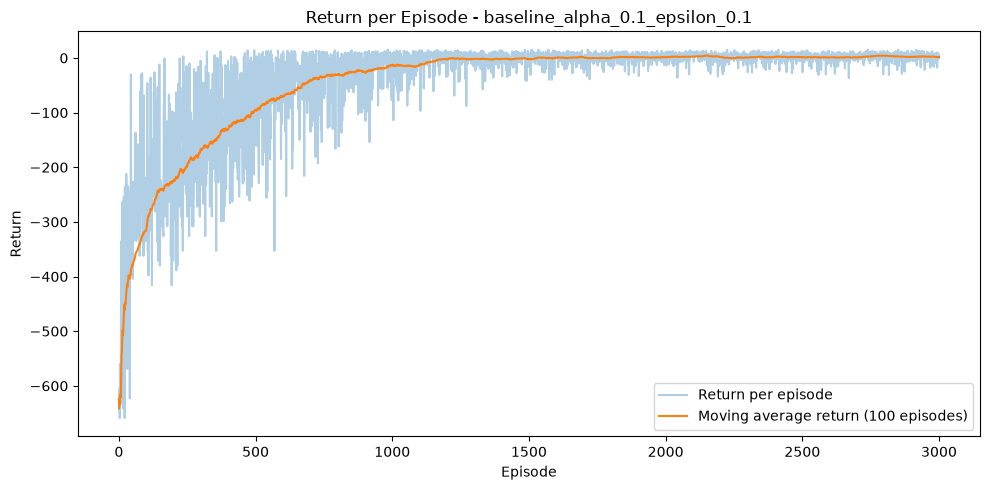

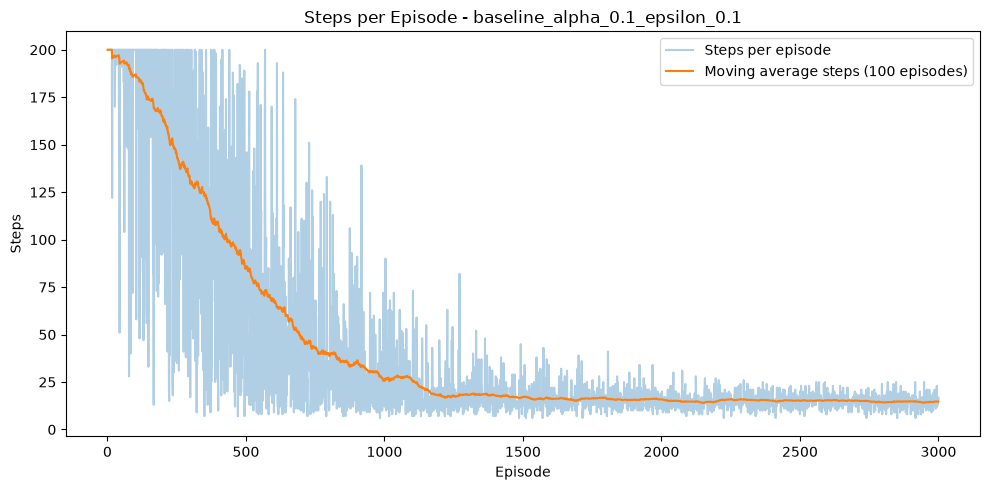

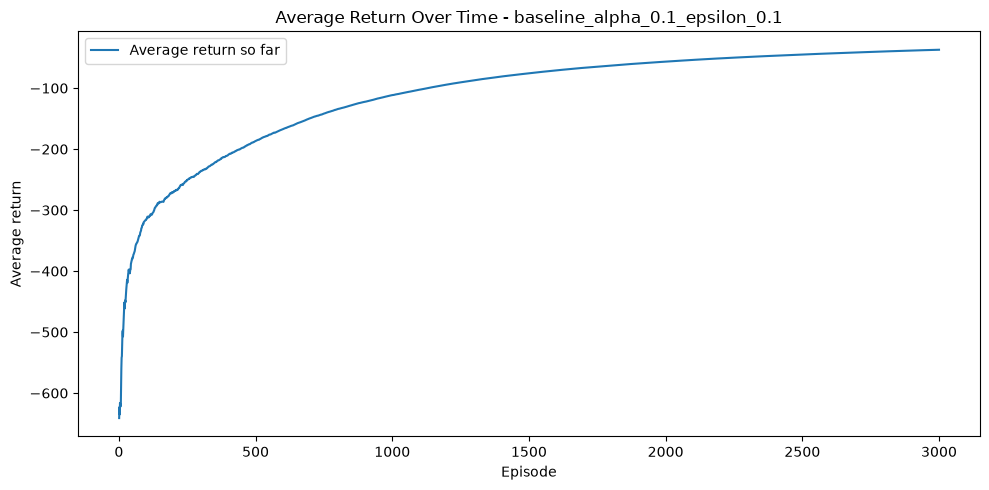

{'experiment': 'baseline_alpha_0.1_epsilon_0.1',
 'alpha': 0.1,
 'epsilon': 0.1,
 'gamma': 0.9,
 'total_episodes': 3000,
 'avg_return_all_training': -37.086,
 'final_100_avg_return': 1.66,
 'avg_steps_all_training': 40.65,
 'final_100_avg_steps': 14.75,
 'eval_avg_return': 3.23,
 'eval_avg_steps': 17.35,
 'eval_success_rate': 0.98}

In [55]:
logger = AppLogger(LOG_FILE)
logger.info("Assignment 2 execution started.")

runner = ExperimentRunner(logger)

baseline_config = ExperimentConfig(
    name="baseline_alpha_0.1_epsilon_0.1",
    alpha=0.1,
    epsilon=0.1,
    gamma=0.9,
    episodes=3000,
    max_steps_per_episode=200,
    eval_episodes=100,
    seed=RANDOM_SEED,
)

baseline_df, baseline_summary = runner.run_experiment(baseline_config, plot=True)
baseline_summary

In [56]:
# Required baseline metrics
baseline_metrics_table = pd.DataFrame({
    "Metric": [
        "Total episodes",
        "Average return per episode",
        "Average steps per episode",
        "Final 100 episodes average return",
        "Final 100 episodes average steps",
        "Evaluation average return",
        "Evaluation average steps",
        "Evaluation success rate",
    ],
    "Value": [
        baseline_summary["total_episodes"],
        baseline_summary["avg_return_all_training"],
        baseline_summary["avg_steps_all_training"],
        baseline_summary["final_100_avg_return"],
        baseline_summary["final_100_avg_steps"],
        baseline_summary["eval_avg_return"],
        baseline_summary["eval_avg_steps"],
        baseline_summary["eval_success_rate"],
    ]
})
baseline_metrics_table

,Metric,Value
0,Total episodes,3000.000
1,Average return per episode,-37.086
2,Average steps per episode,40.650
3,Final 100 episodes average return,1.660
4,Final 100 episodes average steps,14.750
5,Evaluation average return,3.230
6,Evaluation average steps,17.350
7,Evaluation success rate,0.980


### Baseline interpretation

The return should usually improve during training. At the beginning, the agent often takes many bad actions, so the return is low. After more episodes, the Q-table becomes more useful, and the agent should need fewer steps to finish the taxi task.

The moving average curve is more useful than a single episode because reinforcement learning results can be noisy.

## Task 3 - Hyperparameter experiments

This section changes one hyperparameter at a time.

Learning rate experiments:

- $\alpha = 0.01$
- $\alpha = 0.001$
- $\alpha = 0.2$

For these runs, $\epsilon$ stays at the baseline value `0.1`.

Exploration factor experiments:

- $\epsilon = 0.2$
- $\epsilon = 0.3$

For these runs, $\alpha$ stays at the baseline value `0.1`.

Each experiment uses the same discount factor $\gamma = 0.9$.

In [57]:
# Learning rate experiments
alpha_values = [0.01, 0.001, 0.2]

for alpha in alpha_values:
    config = ExperimentConfig(
        name=f"alpha_{alpha}_epsilon_0.1",
        alpha=alpha,
        epsilon=0.1,
        gamma=0.9,
        episodes=3000,
        max_steps_per_episode=200,
        eval_episodes=100,
        seed=RANDOM_SEED,
    )
    runner.run_experiment(config, plot=False)

# Exploration factor experiments
epsilon_values = [0.2, 0.3]

for epsilon in epsilon_values:
    config = ExperimentConfig(
        name=f"alpha_0.1_epsilon_{epsilon}",
        alpha=0.1,
        epsilon=epsilon,
        gamma=0.9,
        episodes=3000,
        max_steps_per_episode=200,
        eval_episodes=100,
        seed=RANDOM_SEED,
    )
    runner.run_experiment(config, plot=False)

summary_df = runner.get_summary_dataframe()
summary_df

2026-06-26 00:01:04 | INFO | Start training | experiment=alpha_0.01_epsilon_0.1 | alpha=0.01 | epsilon=0.1 | gamma=0.9 | episodes=3000
2026-06-26 00:01:05 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=300/3000 | recent_avg_return=-285.47 | recent_avg_steps=186.02
2026-06-26 00:01:06 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=600/3000 | recent_avg_return=-257.10 | recent_avg_steps=183.91
2026-06-26 00:01:07 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=900/3000 | recent_avg_return=-239.47 | recent_avg_steps=175.43
2026-06-26 00:01:08 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=1200/3000 | recent_avg_return=-219.81 | recent_avg_steps=165.15
2026-06-26 00:01:09 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=1500/3000 | recent_avg_return=-208.04 | recent_avg_steps=157.83
2026-06-26 00:01:09 | INFO | Progress | experiment=alpha_0.01_epsilon_0.1 | episode=1800/3000 | recent_avg_return=-191.51 | rece

,experiment,alpha,epsilon,gamma,total_episodes,avg_return_all_training,final_100_avg_return,avg_steps_all_training,final_100_avg_steps,eval_avg_return,eval_avg_steps,eval_success_rate
0,baseline_alpha_0.1_epsilon_0.1,0.100,0.1,0.9,3000,-37.086000,1.66,40.650000,14.75,3.23,17.35,0.98
1,alpha_0.01_epsilon_0.1,0.010,0.1,0.9,3000,-203.324667,-131.26,153.157667,112.45,-215.76,198.06,0.01
2,alpha_0.001_epsilon_0.1,0.001,0.1,0.9,3000,-262.497000,-252.69,186.242000,183.81,-235.64,200.00,0.00
3,alpha_0.2_epsilon_0.1,0.200,0.1,0.9,3000,-20.446333,2.96,29.130333,14.53,7.30,13.70,1.00
4,alpha_0.1_epsilon_0.2,0.100,0.2,0.9,3000,-51.485000,-3.65,43.403000,16.64,3.23,17.35,0.98
5,alpha_0.1_epsilon_0.3,0.100,0.3,0.9,3000,-69.175667,-12.90,46.682667,18.96,1.21,19.16,0.97


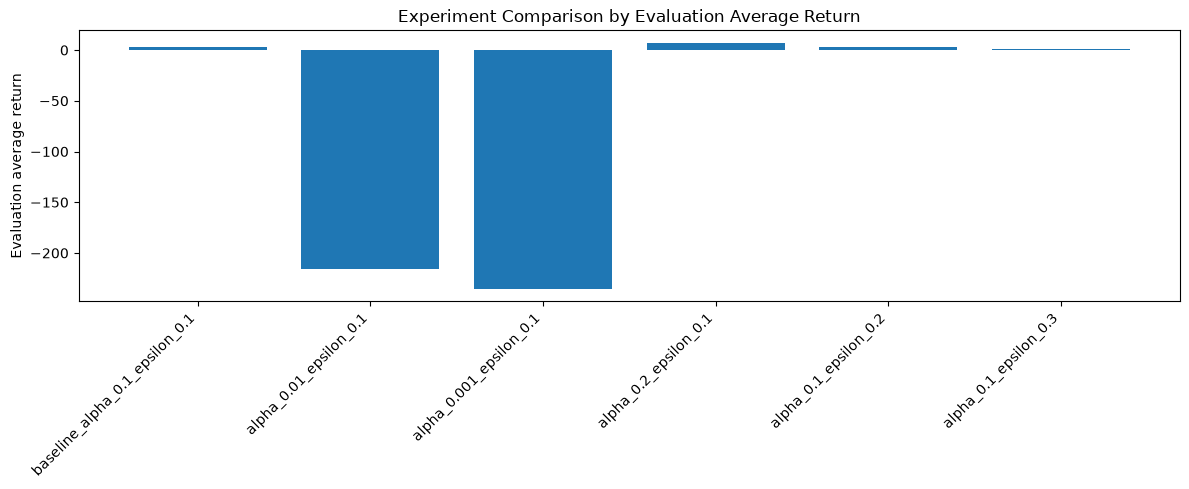

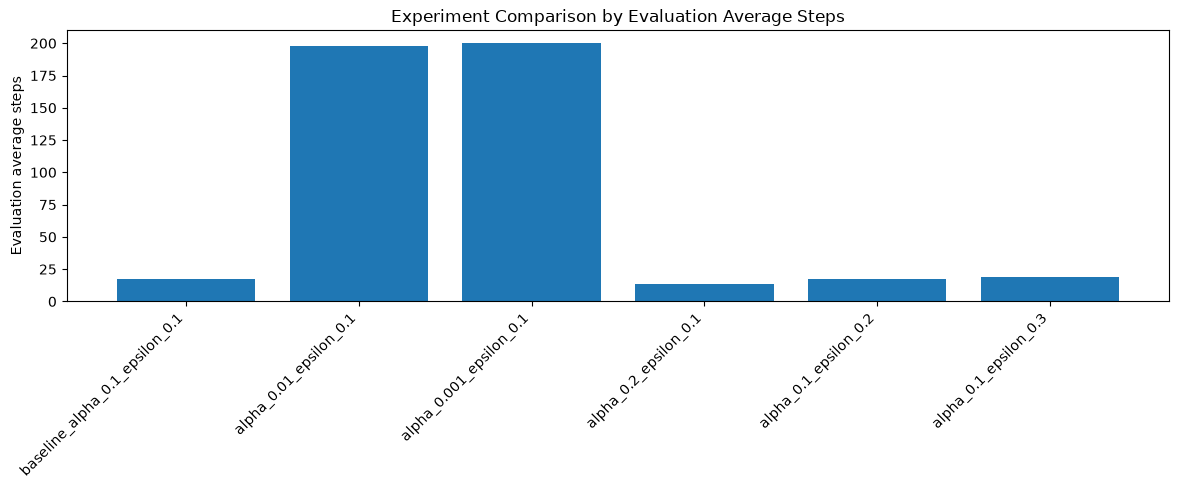

,experiment,alpha,epsilon,gamma,total_episodes,avg_return_all_training,final_100_avg_return,avg_steps_all_training,final_100_avg_steps,eval_avg_return,eval_avg_steps,eval_success_rate
3,alpha_0.2_epsilon_0.1,0.200,0.1,0.9,3000,-20.446333,2.96,29.130333,14.53,7.30,13.70,1.00
0,baseline_alpha_0.1_epsilon_0.1,0.100,0.1,0.9,3000,-37.086000,1.66,40.650000,14.75,3.23,17.35,0.98
4,alpha_0.1_epsilon_0.2,0.100,0.2,0.9,3000,-51.485000,-3.65,43.403000,16.64,3.23,17.35,0.98
5,alpha_0.1_epsilon_0.3,0.100,0.3,0.9,3000,-69.175667,-12.90,46.682667,18.96,1.21,19.16,0.97
1,alpha_0.01_epsilon_0.1,0.010,0.1,0.9,3000,-203.324667,-131.26,153.157667,112.45,-215.76,198.06,0.01
2,alpha_0.001_epsilon_0.1,0.001,0.1,0.9,3000,-262.497000,-252.69,186.242000,183.81,-235.64,200.00,0.00


In [58]:
PlotManager.plot_experiment_comparison(summary_df)
summary_df.sort_values(by=["eval_avg_return", "eval_success_rate"], ascending=False)

### Hyperparameter experiment interpretation

After running the experiments, compare the summary table with the baseline.

General interpretation:

- A very small learning rate such as `0.001` may learn slowly because each Q-value update is tiny.
- A moderate learning rate can improve steadily.
- A large learning rate such as `0.2` may learn faster, but it can also be less stable.
- A larger exploration factor such as `0.2` or `0.3` makes the agent try more random actions. This can help the agent discover useful paths, but it can also reduce short-term return because random actions may be illegal or inefficient.

The best result should be selected based on the evaluation average return, evaluation success rate, and evaluation average steps.

## Task 4 - Best combination experiment

The following cell selects one learning rate and one exploration factor using the previous experiments.

The method is:

1. Pick the best learning rate from the baseline learning rate and the three learning rate experiments.
2. Pick the best exploration factor from the baseline exploration factor and the two exploration experiments.
3. Re-run Q-Learning using this selected pair.

This is a practical selection rule. The final explanation should still mention what happened in your actual output table.

In [59]:
# Select the best alpha from experiments where epsilon is 0.1.
alpha_candidate_names = ["baseline_alpha_0.1_epsilon_0.1"] + [f"alpha_{a}_epsilon_0.1" for a in alpha_values]
alpha_candidates = summary_df[summary_df["experiment"].isin(alpha_candidate_names)].copy()
alpha_candidates = alpha_candidates.sort_values(
    by=["eval_avg_return", "eval_success_rate", "eval_avg_steps"],
    ascending=[False, False, True]
)
best_alpha = float(alpha_candidates.iloc[0]["alpha"])

# Select the best epsilon from experiments where alpha is 0.1.
epsilon_candidate_names = ["baseline_alpha_0.1_epsilon_0.1"] + [f"alpha_0.1_epsilon_{e}" for e in epsilon_values]
epsilon_candidates = summary_df[summary_df["experiment"].isin(epsilon_candidate_names)].copy()
epsilon_candidates = epsilon_candidates.sort_values(
    by=["eval_avg_return", "eval_success_rate", "eval_avg_steps"],
    ascending=[False, False, True]
)
best_epsilon = float(epsilon_candidates.iloc[0]["epsilon"])

best_alpha, best_epsilon

(0.2, 0.1)

2026-06-26 00:01:28 | INFO | Start training | experiment=best_combination_alpha_0.2_epsilon_0.1 | alpha=0.2 | epsilon=0.1 | gamma=0.9 | episodes=3000
2026-06-26 00:01:29 | INFO | Progress | experiment=best_combination_alpha_0.2_epsilon_0.1 | episode=300/3000 | recent_avg_return=-184.89 | recent_avg_steps=129.20
2026-06-26 00:01:29 | INFO | Progress | experiment=best_combination_alpha_0.2_epsilon_0.1 | episode=600/3000 | recent_avg_return=-28.91 | recent_avg_steps=37.85
2026-06-26 00:01:29 | INFO | Progress | experiment=best_combination_alpha_0.2_epsilon_0.1 | episode=900/3000 | recent_avg_return=-3.29 | recent_avg_steps=18.65
2026-06-26 00:01:30 | INFO | Progress | experiment=best_combination_alpha_0.2_epsilon_0.1 | episode=1200/3000 | recent_avg_return=1.86 | recent_avg_steps=15.15
2026-06-26 00:01:30 | INFO | Progress | experiment=best_combination_alpha_0.2_epsilon_0.1 | episode=1500/3000 | recent_avg_return=1.53 | recent_avg_steps=14.64
2026-06-26 00:01:30 | INFO | Progress | experi

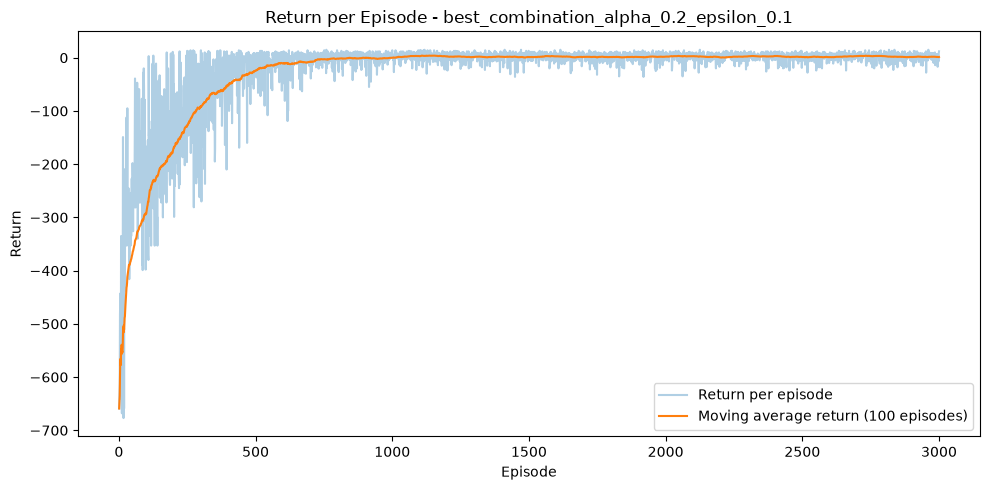

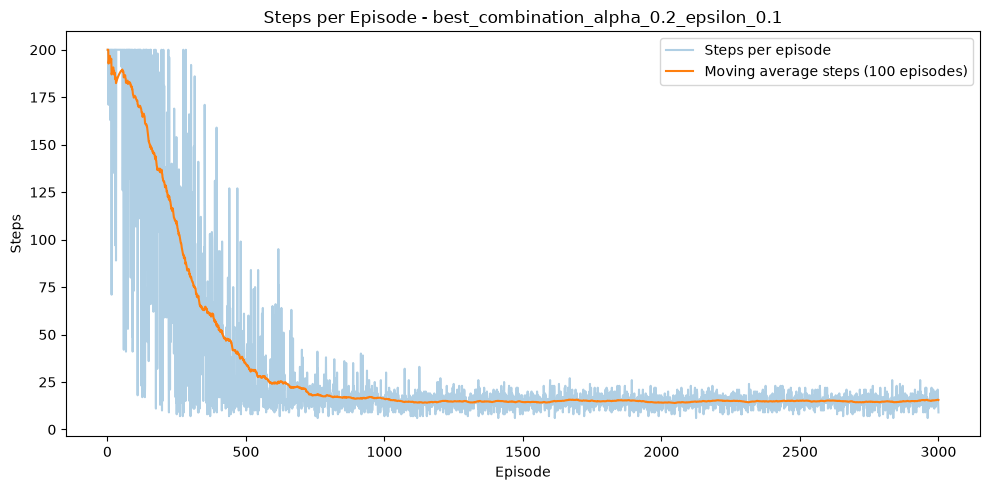

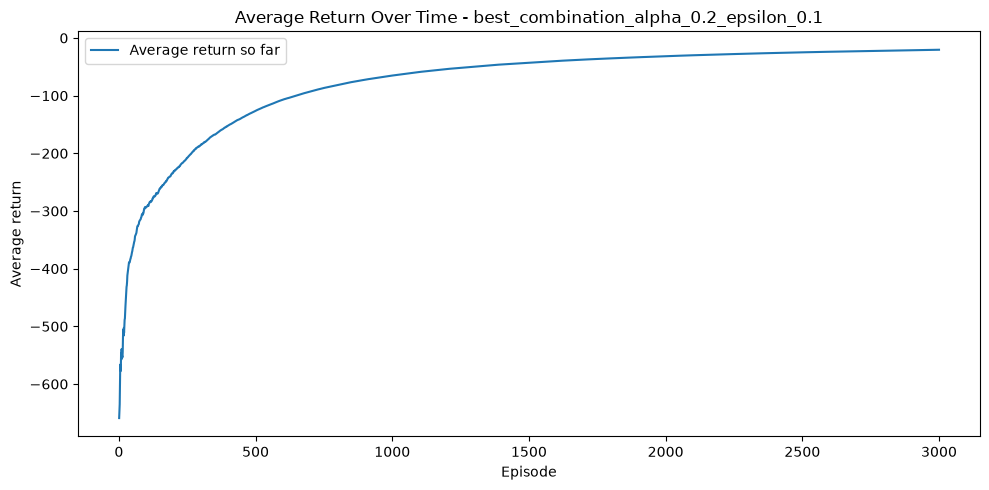

,experiment,alpha,epsilon,gamma,total_episodes,avg_return_all_training,final_100_avg_return,avg_steps_all_training,final_100_avg_steps,eval_avg_return,eval_avg_steps,eval_success_rate
6,best_combination_alpha_0.2_epsilon_0.1,0.200,0.1,0.9,3000,-20.380333,1.41,28.992333,15.54,7.68,13.32,1.00
3,alpha_0.2_epsilon_0.1,0.200,0.1,0.9,3000,-20.446333,2.96,29.130333,14.53,7.30,13.70,1.00
0,baseline_alpha_0.1_epsilon_0.1,0.100,0.1,0.9,3000,-37.086000,1.66,40.650000,14.75,3.23,17.35,0.98
4,alpha_0.1_epsilon_0.2,0.100,0.2,0.9,3000,-51.485000,-3.65,43.403000,16.64,3.23,17.35,0.98
5,alpha_0.1_epsilon_0.3,0.100,0.3,0.9,3000,-69.175667,-12.90,46.682667,18.96,1.21,19.16,0.97
1,alpha_0.01_epsilon_0.1,0.010,0.1,0.9,3000,-203.324667,-131.26,153.157667,112.45,-215.76,198.06,0.01
2,alpha_0.001_epsilon_0.1,0.001,0.1,0.9,3000,-262.497000,-252.69,186.242000,183.81,-235.64,200.00,0.00


In [60]:
best_config = ExperimentConfig(
    name=f"best_combination_alpha_{best_alpha}_epsilon_{best_epsilon}",
    alpha=best_alpha,
    epsilon=best_epsilon,
    gamma=0.9,
    episodes=3000,
    max_steps_per_episode=200,
    eval_episodes=100,
    seed=RANDOM_SEED + 100,
)

best_df, best_summary = runner.run_experiment(best_config, plot=True)

final_summary_df = runner.get_summary_dataframe()
final_summary_df.sort_values(by=["eval_avg_return", "eval_success_rate"], ascending=False)

In [61]:
logger.info("Assignment 2 execution finished.")

print(f"Log file saved to: {LOG_FILE}")
print(f"Plots saved to: {PLOTS_DIR.resolve()}")

2026-06-26 00:01:31 | INFO | Assignment 2 execution finished.


Log file saved to: assignment2_execution.log
Plots saved to: /Users/chence/work/CSCN8020/Assignment2/plots


### Best combination interpretation

The selected best combination is based on the previous experiment results. The important comparison is between the baseline row and the best-combination row in the final summary table.

A good combination should usually have:

- higher evaluation average return,
- lower evaluation average steps,
- high success rate.

If the best combination is the same as the baseline, that is still a valid result. It means the baseline settings were already strong for this Taxi problem in this run.

## Mapping Python code to Q-Learning pseudocode

This table maps the implementation to the Q-Learning pseudocode from Sutton and Barto style Q-Learning.

| Pseudocode idea | Python code in this notebook |
|---|---|
| Initialize $Q(s,a)$ | `QLearningAgent.__init__()` creates `self.q_table = np.zeros((state_count, action_count))` |
| Start each episode | `QLearningTrainer.train()` has `for episode in range(...)` |
| Observe current state $S$ | `state = self.env_manager.reset()` |
| Choose action $A$ | `action = self.agent.choose_action(state)` |
| Take action $A$ | `next_state, reward, done, _ = self.env_manager.step(action)` |
| Observe reward $R$ and next state $S'$ | `reward` and `next_state` returned by `step()` |
| Apply Q-Learning update | `self.agent.learn(state, action, reward, next_state, done)` |
| Repeat until terminal state | `while not done and steps < max_steps_per_episode` |
| Improve policy | `greedy_action()` uses the learned Q-table to select the best action |

## Five required talking points

### Talking point 1 - Q-table initialization

A key feature of Q-Learning is that it learns a value for every state-action pair. In this notebook, the Q-table is initialized in `QLearningAgent.__init__()` with zeros. This connects to the pseudocode step "initialize Q(s, a)".

One challenge is that the Taxi environment has 500 states and 6 actions, so the table has 3000 values. This is small enough for tabular Q-Learning, but it still needs many episodes to learn good values.

This is reinforcement learning because the agent does not receive correct labeled actions. It learns from rewards after taking actions in the environment.

### Talking point 2 - Epsilon-greedy action selection

A key feature is the balance between exploration and exploitation. The method `choose_action()` uses epsilon-greedy action selection. Sometimes it selects a random action, and sometimes it selects the best known action from the Q-table.

One challenge is choosing a useful epsilon value. If epsilon is too low, the agent may not explore enough. If epsilon is too high, the agent may keep taking too many random actions.

This is reinforcement learning because the action is chosen during interaction with the environment, and the result affects future Q-values.

### Talking point 3 - Temporal-difference update

A key feature of Q-Learning is the temporal-difference update. The method `learn()` updates the current Q-value using the reward and the best future Q-value from the next state.

One challenge is handling terminal states. In the code, if `done` is true, the next best value is set to `0.0`. This prevents the agent from using future value after the episode ends.

This is reinforcement learning because the update uses experience from one transition: current state, action, reward, and next state.

### Talking point 4 - Episode loop and rewards

A key feature is sequential decision-making. The training loop repeats actions until the episode finishes or reaches the maximum step limit.

One challenge is that illegal pickup and drop-off actions give a strong penalty of `-10`. At the beginning, the agent may make these mistakes often, so early returns can be very low.

This is reinforcement learning because the agent learns a behavior policy through trial and error, not from a fixed training dataset.

### Talking point 5 - Policy evaluation and hyperparameter testing

A key feature is policy improvement. After training, `evaluate_policy()` tests the greedy policy using the learned Q-table and no exploration.

One challenge is that results can change because training is partly random. This notebook uses a fixed random seed to make the results easier to reproduce.

This is reinforcement learning because the quality of the learned policy is measured by returns, steps, and success rate in the environment.

## Final conclusion

This notebook implemented Q-Learning for the Taxi Gymnasium environment using object-oriented Python code. The implementation includes environment handling, agent behavior, training, metrics collection, plotting, evaluation, and logging.

The baseline experiment shows how the agent learns from rewards over many episodes. The hyperparameter experiments show that learning rate and exploration factor can change the learning speed and final policy quality. The best-combination experiment uses the observed results to select a stronger parameter pair and compare it with the baseline.

Overall, this problem is a good example of reinforcement learning because the agent improves by interacting with an environment, receiving rewards, and updating action values over time.

## AI-use note

I used AI support to help organize the code structure and explanation. I reviewed the code and explanations and I am responsible for understanding and verifying the final submitted work.